# 🎯 MODEL 2: ENHANCED RECOMMENDATION SYSTEM
**Amazon Electronics - Trust-Based Collaborative Filtering**

---

## 📋 PROJECT OVERVIEW:

**Pipeline:** Fake Review Detection → **Trust Scoring** → Multi-Level Filtering → **Recommendations**

**ENHANCED APPROACH:**
- Load trust-scored dataset with user/review trust scores (0-1)
- Create multiple trust-filtered datasets (High, Medium, All)
- Train ALS models on each trust level
- Compare recommendation quality across trust thresholds
- Demonstrate business impact of trust-based filtering

---

## 🎯 EXPECTED OUTCOMES:
- **Multi-Level Analysis**: 4 different trust-filtered models
- **Progressive Improvement**: Show quality gains with higher trust thresholds
- **Trust-Weighted Recommendations**: Sophisticated ML pipeline
- **Business ROI**: Quantified value of fake review detection

---

**⏰ UPDATED TIME ALLOCATION:**
- Hours 1-2: Enhanced Data Loading & Trust Analysis
- Hours 3-4: Multi-Level ALS Training
- Hours 5-6: Comprehensive Evaluation
- Hours 7-8: Interactive Demo & Business Impact

---
# 🔧 ENVIRONMENT SETUP
---

In [1]:
# Install required packages
!pip install pyspark -q
!pip install matplotlib seaborn -q

print("✅ Packages installed!")

✅ Packages installed!


In [15]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, desc, sum, when, count, avg, row_number
from pyspark.sql.types import *
import builtins # Import builtins to explicitly access Python's max function

# MLlib for recommendations
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

print("✅ All imports successful!")

✅ All imports successful!


In [3]:
# Initialize Spark Session - Optimized for Colab Pro and large string IDs
try:
    spark.stop()
except:
    pass

spark = SparkSession.builder \
    .appName("TrustBasedRecommendations") \
    .config("spark.driver.memory", "8g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.kryoserializer.buffer", "128m") \
    .config("spark.sql.execution.arrow.maxRecordsPerBatch", "1000") \
    .config("spark.sql.adaptive.advisoryPartitionSizeInBytes", "128MB") \
    .getOrCreate()

print(f"✅ Spark {spark.version} session created")
print(f"📊 Driver Memory: 8GB")
print(f"🚀 Optimized for Colab Pro")
print(f"📦 Kryo buffers set to max 512m")
print(f"🔀 Shuffle partitions reduced to 32")

# Test Spark
test_df = spark.range(5)
print(f"\n🧪 Spark test - Row count: {test_df.count()}")
print("✅ Spark is working!")

✅ Spark 3.5.1 session created
📊 Driver Memory: 8GB
🚀 Optimized for Colab Pro
📦 Kryo buffers set to max 512m
🔀 Shuffle partitions reduced to 32

🧪 Spark test - Row count: 5
✅ Spark is working!


---
# 📊 ENHANCED DATA LOADING WITH TRUST SCORES
**Hours 1-2: Load Trust-Scored Dataset + Analysis**
---

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted!")

Mounted at /content/drive
✅ Google Drive mounted!


In [5]:
# Define enhanced data paths
# 🔄 UPDATE THESE PATHS to match your Google Drive structure

BASE_PATH = "/content/drive/MyDrive/SJSU/DATA 228/Amazon 02"

# ENHANCED DATASET with trust scores (NEW!)
TRUST_REVIEWS_PATH = f"{BASE_PATH}/reviews_with_trust_score.parquet"

# Fallback/comparison paths
REVIEWS_PATH = f"{BASE_PATH}/reviews_eda_sample.parquet"
META_PATH = f"{BASE_PATH}/meta.parquet"
FAKE_DETECTION_PATH = f"{BASE_PATH}/fake_review_demo/"

LOW_TRUST_REVIEWS = f"{FAKE_DETECTION_PATH}low_trust_reviews.csv"
SUSPICIOUS_USERS = f"{FAKE_DETECTION_PATH}suspicious_users.csv"
CLUSTER_STATS = f"{FAKE_DETECTION_PATH}cluster_statistics.csv"

# Output path for results
OUTPUT_PATH = f"{BASE_PATH}/Model2_Results/"

print("📁 Enhanced data paths configured:")
print(f"   🎯 Trust-scored reviews: {TRUST_REVIEWS_PATH}")
print(f"   📊 Original reviews: {REVIEWS_PATH}")
print(f"   📦 Metadata: {META_PATH}")
print(f"   🔍 Fake detection: {FAKE_DETECTION_PATH}")
print(f"   📁 Output: {OUTPUT_PATH}")

# Create output directory
import os
os.makedirs(OUTPUT_PATH, exist_ok=True)
print("\n✅ Output directory ready")

📁 Enhanced data paths configured:
   🎯 Trust-scored reviews: /content/drive/MyDrive/SJSU/DATA 228/Amazon 02/reviews_with_trust_score.parquet
   📊 Original reviews: /content/drive/MyDrive/SJSU/DATA 228/Amazon 02/reviews_eda_sample.parquet
   📦 Metadata: /content/drive/MyDrive/SJSU/DATA 228/Amazon 02/meta.parquet
   🔍 Fake detection: /content/drive/MyDrive/SJSU/DATA 228/Amazon 02/fake_review_demo/
   📁 Output: /content/drive/MyDrive/SJSU/DATA 228/Amazon 02/Model2_Results/

✅ Output directory ready


In [6]:
# Load the enhanced trust-scored dataset
print("📥 Loading enhanced dataset with trust scores...\n")

try:
    # Load the complete dataset with trust scores
    reviews_with_trust = spark.read.parquet(TRUST_REVIEWS_PATH)
    total_reviews = reviews_with_trust.count()

    print(f"✅ Enhanced dataset loaded: {total_reviews:,} reviews")
    print(f"📋 Total columns: {len(reviews_with_trust.columns)}")

    # Show the trust-related columns
    print("\n🎯 Trust Score Columns Found:")
    trust_columns = [col for col in reviews_with_trust.columns if 'trust' in col.lower()]
    for col_name in trust_columns:
        print(f"   - {col_name}")

    # Show sample data with trust scores
    print("\n👀 Sample reviews with trust scores:")
    sample_cols = ['user_id', 'asin', 'rating', 'verified_purchase'] + trust_columns
    reviews_with_trust.select(*sample_cols).show(5, truncate=False)

    # Trust score statistics
    print("\n📊 Trust Score Statistics:")
    trust_stats = reviews_with_trust.select(*trust_columns).describe()
    trust_stats.show()

    # Cache for performance
    reviews_with_trust.cache()
    print("\n💾 Enhanced dataset cached for performance")

    # Set success flag
    trust_data_loaded = True

except Exception as e:
    print(f"❌ Error loading enhanced dataset: {e}")
    print("🔄 Falling back to original dataset...")

    # Fallback to original data
    reviews_with_trust = spark.read.parquet(REVIEWS_PATH)
    total_reviews = reviews_with_trust.count()
    print(f"✅ Fallback dataset loaded: {total_reviews:,} reviews")

    trust_data_loaded = False

# After the try/except block, add:
if not trust_data_loaded:
    print("\n🔄 Loading fallback CSV filtering approach...")

    # Load the CSV files as backup
    try:
        low_trust_pd = pd.read_csv(LOW_TRUST_REVIEWS)
        suspicious_users_pd = pd.read_csv(SUSPICIOUS_USERS)

        print(f"✅ CSV fallback loaded:")
        print(f"   Low trust reviews: {len(low_trust_pd):,}")
        print(f"   Suspicious users: {len(suspicious_users_pd):,}")

        # Convert to Spark DataFrames for filtering
        if 'user_id' in low_trust_pd.columns:
            low_trust_spark = spark.createDataFrame(low_trust_pd[['user_id', 'asin']].drop_duplicates())
        if 'user_id' in suspicious_users_pd.columns:
            suspicious_users_spark = spark.createDataFrame(suspicious_users_pd[['user_id']].drop_duplicates())

        csv_filtering_available = True

    except Exception as e:
        print(f"❌ CSV fallback also failed: {e}")
        csv_filtering_available = False
print(f"\n🎯 Dataset Status: {'Enhanced with Trust Scores' if trust_data_loaded else 'Original Dataset (No Trust Scores)'}")

📥 Loading enhanced dataset with trust scores...

✅ Enhanced dataset loaded: 1,978,436 reviews
📋 Total columns: 21

🎯 Trust Score Columns Found:
   - user_trust_score
   - review_trust_score
   - trust_level

👀 Sample reviews with trust scores:
+----------------------------+----------+------+-----------------+------------------+-------------------+-----------+
|user_id                     |asin      |rating|verified_purchase|user_trust_score  |review_trust_score |trust_level|
+----------------------------+----------+------+-----------------+------------------+-------------------+-----------+
|AGFPQCUEVTD3AFRO4O3ZV3BQQE6Q|0511189877|5.0   |true             |0.9995967741935484|0.7634387096774194 |High       |
|AED6VAFH2YJU36ZC2U4YJZEMJVJQ|0511189877|5.0   |true             |0.7467539215686274|0.561501568627451  |Medium     |
|AHVN6QX3ZZFK3U7PIO6F4VW5KJUQ|0511189877|5.0   |true             |0.5               |0.45640000000000003|Medium     |
|AGDI7MTBGKMYYEIL235BOSN6NMLQ|0511189877|5.0   |

📊 TRUST SCORE ANALYSIS



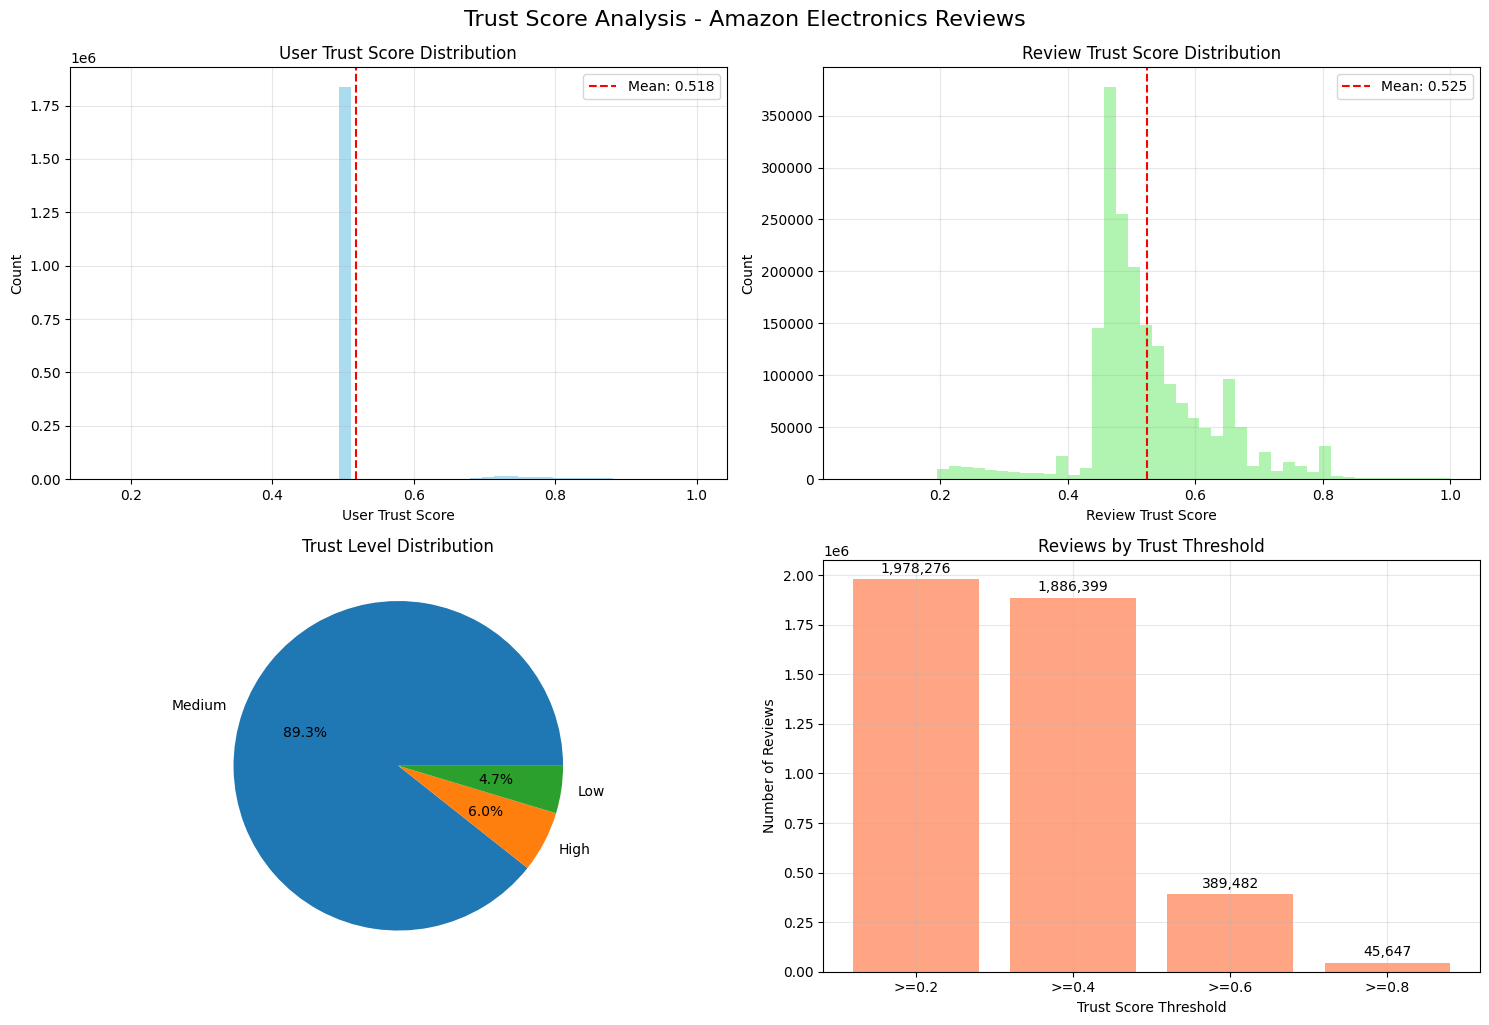


📈 TRUST ANALYSIS SUMMARY:
   📊 Total reviews: 1,978,436
   👤 Avg user trust: 0.518
   📝 Avg review trust: 0.525
   🎯 Trust >= 0.2: 1,978,276 reviews (100.0%)
   🎯 Trust >= 0.4: 1,886,399 reviews (95.3%)
   🎯 Trust >= 0.6: 389,482 reviews (19.7%)
   🎯 Trust >= 0.8: 45,647 reviews (2.3%)


In [7]:
# Analyze trust score distributions (if trust data available)
if trust_data_loaded and 'user_trust_score' in reviews_with_trust.columns:
    print("📊 TRUST SCORE ANALYSIS\n")

    # Trust score distribution analysis
    trust_analysis = reviews_with_trust.select(
        'user_trust_score', 'review_trust_score', 'trust_level'
    ).toPandas()

    # Create trust distribution visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # User trust score distribution
    axes[0,0].hist(trust_analysis['user_trust_score'].dropna(), bins=50, alpha=0.7, color='skyblue')
    axes[0,0].axvline(trust_analysis['user_trust_score'].mean(), color='red', linestyle='--',
                     label=f'Mean: {trust_analysis["user_trust_score"].mean():.3f}')
    axes[0,0].set_title('User Trust Score Distribution')
    axes[0,0].set_xlabel('User Trust Score')
    axes[0,0].set_ylabel('Count')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # Review trust score distribution
    axes[0,1].hist(trust_analysis['review_trust_score'].dropna(), bins=50, alpha=0.7, color='lightgreen')
    axes[0,1].axvline(trust_analysis['review_trust_score'].mean(), color='red', linestyle='--',
                     label=f'Mean: {trust_analysis["review_trust_score"].mean():.3f}')
    axes[0,1].set_title('Review Trust Score Distribution')
    axes[0,1].set_xlabel('Review Trust Score')
    axes[0,1].set_ylabel('Count')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # Trust level distribution
    if 'trust_level' in trust_analysis.columns:
        trust_level_counts = trust_analysis['trust_level'].value_counts()
        axes[1,0].pie(trust_level_counts.values, labels=trust_level_counts.index, autopct='%1.1f%%')
        axes[1,0].set_title('Trust Level Distribution')

    # Trust threshold analysis
    thresholds = [0.2, 0.4, 0.6, 0.8]
    threshold_counts = []
    for threshold in thresholds:
        count = (trust_analysis['review_trust_score'] >= threshold).sum()
        threshold_counts.append(count)

    axes[1,1].bar([f'>={t}' for t in thresholds], threshold_counts, alpha=0.7, color='coral')
    axes[1,1].set_title('Reviews by Trust Threshold')
    axes[1,1].set_xlabel('Trust Score Threshold')
    axes[1,1].set_ylabel('Number of Reviews')

    # Add count labels on bars
    for i, count in enumerate(threshold_counts):
        axes[1,1].text(i, count + np.max(threshold_counts)*0.01, f'{count:,}',
                      ha='center', va='bottom')

    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('Trust Score Analysis - Amazon Electronics Reviews', fontsize=16, y=1.02)
    plt.show()

    # Print summary statistics
    print("\n📈 TRUST ANALYSIS SUMMARY:")
    print(f"   📊 Total reviews: {len(trust_analysis):,}")
    print(f"   👤 Avg user trust: {trust_analysis['user_trust_score'].mean():.3f}")
    print(f"   📝 Avg review trust: {trust_analysis['review_trust_score'].mean():.3f}")

    for threshold in thresholds:
        count = (trust_analysis['review_trust_score'] >= threshold).sum()
        percentage = (count / len(trust_analysis)) * 100
        print(f"   🎯 Trust >= {threshold}: {count:,} reviews ({percentage:.1f}%)")

else:
    print("⚠️ Trust score analysis skipped - using original dataset")
    print("📊 Will proceed with basic fake review filtering approach")

---
# 🎯 MULTI-LEVEL TRUST FILTERING
**Create Multiple Trust-Filtered Datasets for Comparison**
---

In [8]:
# Create multiple datasets with different trust thresholds
print("🔧 Creating multi-level trust-filtered datasets...\n")

# Select essential columns for recommendations
essential_columns = ['user_id', 'asin', 'rating']
if 'timestamp' in reviews_with_trust.columns:
    essential_columns.append('timestamp')
if 'verified_purchase' in reviews_with_trust.columns:
    essential_columns.append('verified_purchase')

# Add trust columns if available
if trust_data_loaded:
    trust_cols = [col for col in reviews_with_trust.columns if 'trust' in col.lower()]
    essential_columns.extend(trust_cols)

# Base dataset - clean and prepare
base_reviews = reviews_with_trust.select(*essential_columns)
base_reviews = base_reviews.filter(
    (col("user_id").isNotNull()) &
    (col("asin").isNotNull()) &
    (col("rating").isNotNull()) &
    (col("rating").between(1, 5))
)

print(f"📊 Base dataset: {base_reviews.count():,} reviews")

# Create trust-filtered datasets
datasets = {}

if trust_data_loaded and 'review_trust_score' in base_reviews.columns:
    # Dataset 1: All reviews (baseline)
    datasets['all'] = {
        'data': base_reviews,
        'name': 'All Reviews (Baseline)',
        'description': 'Complete dataset including all reviews'
    }

    # Dataset 2: Medium trust (>= 0.4)
    datasets['medium'] = {
        'data': base_reviews.filter(col("review_trust_score") >= 0.4),
        'name': 'Medium Trust (≥0.4)',
        'description': 'Reviews with trust score ≥ 0.4'
    }

    # Dataset 3: High trust (>= 0.6)
    datasets['high'] = {
        'data': base_reviews.filter(col("review_trust_score") >= 0.6),
        'name': 'High Trust (≥0.6)',
        'description': 'Reviews with trust score ≥ 0.6'
    }

    # Dataset 4: Very high trust (>= 0.8)
    datasets['very_high'] = {
        'data': base_reviews.filter(col("review_trust_score") >= 0.8),
        'name': 'Very High Trust (≥0.8)',
        'description': 'Reviews with trust score ≥ 0.8'
    }

else:
    # Fallback: Use all data as single dataset
    datasets['all'] = {
        'data': base_reviews,
        'name': 'All Reviews',
        'description': 'Complete dataset (no trust filtering available)'
    }

# Display dataset statistics
print("\n📈 DATASET COMPARISON:")
print("=" * 80)
print(f"{'Dataset':<20} {'Count':<12} {'Users':<8} {'Items':<8} {'Avg Rating':<12} {'Description'}")
print("=" * 80)

for key, dataset_info in datasets.items():
    data = dataset_info['data']
    name = dataset_info['name']
    description = dataset_info['description']

    # Calculate statistics
    count = data.count()
    users = data.select("user_id").distinct().count()
    items = data.select("asin").distinct().count()
    avg_rating = data.select(avg("rating")).collect()[0][0]

    print(f"{name:<20} {count:<12,} {users:<8,} {items:<8,} {avg_rating:<12.3f} {description}")

    # Cache for performance
    data.cache()

print("=" * 80)
print("\n💾 All datasets cached for model training")

# Store dataset info for later use
print(f"\n✅ Created {len(datasets)} datasets for ALS training and comparison")

🔧 Creating multi-level trust-filtered datasets...

📊 Base dataset: 1,978,436 reviews

📈 DATASET COMPARISON:
Dataset              Count        Users    Items    Avg Rating   Description
All Reviews (Baseline) 1,978,436    1,741,238 493,905  4.097        Complete dataset including all reviews
Medium Trust (≥0.4)  1,886,399    1,666,224 477,980  4.103        Reviews with trust score ≥ 0.4
High Trust (≥0.6)    389,482      331,925  177,061  3.814        Reviews with trust score ≥ 0.6
Very High Trust (≥0.8) 45,647       38,058   35,826   3.798        Reviews with trust score ≥ 0.8

💾 All datasets cached for model training

✅ Created 4 datasets for ALS training and comparison


---
# 🤖 MULTI-LEVEL ALS MODEL TRAINING
**Hours 3-4: Train ALS Models on Each Trust Level**
---

In [9]:
# Prepare data for ALS training
print("🤖 MULTI-LEVEL ALS MODEL TRAINING\n")

def prepare_als_data(df):
    """
    Prepare dataframe for ALS training by creating user and item indices
    """
    # String indexer for users
    user_indexer = StringIndexer(inputCol="user_id", outputCol="user_idx", handleInvalid="keep")

    # String indexer for items
    item_indexer = StringIndexer(inputCol="asin", outputCol="item_idx", handleInvalid="keep")

    # Create pipeline
    indexer_pipeline = Pipeline(stages=[user_indexer, item_indexer])

    # Fit and transform
    indexer_model = indexer_pipeline.fit(df)
    indexed_df = indexer_model.transform(df)

    return indexed_df, indexer_model

def train_als_model(df, dataset_name, rank=10, maxIter=10, regParam=0.1):
    """
    Train ALS model on given dataset
    """
    print(f"\n🔧 Training ALS model for {dataset_name}...")

    # Prepare data
    indexed_df, indexer_model = prepare_als_data(df)

    # Split into train/test
    train_data, test_data = indexed_df.randomSplit([0.8, 0.2], seed=42)

    print(f"   📊 Train: {train_data.count():,} reviews")
    print(f"   📊 Test: {test_data.count():,} reviews")

    # Initialize ALS
    als = ALS(
        userCol="user_idx",
        itemCol="item_idx",
        ratingCol="rating",
        rank=rank,
        maxIter=maxIter,
        regParam=regParam,
        coldStartStrategy="drop",
        seed=42
    )

    # Train model
    model = als.fit(train_data)

    # Make predictions
    predictions = model.transform(test_data)

    # Calculate RMSE
    evaluator = RegressionEvaluator(
        metricName="rmse",
        labelCol="rating",
        predictionCol="prediction"
    )

    rmse = evaluator.evaluate(predictions.filter(col("prediction").isNotNull()))

    print(f"   ✅ Training complete - RMSE: {rmse:.4f}")

    return {
        'model': model,
        'indexer_model': indexer_model,
        'predictions': predictions,
        'train_data': train_data,
        'test_data': test_data,
        'rmse': rmse,
        'dataset_name': dataset_name
    }

# Train models on all datasets
trained_models = {}
performance_results = []

print("🚀 Starting ALS training on all trust levels...")
print("=" * 60)

for key, dataset_info in datasets.items():
    dataset_name = dataset_info['name']
    data = dataset_info['data']

    try:
        # Train ALS model
        model_result = train_als_model(data, dataset_name)
        trained_models[key] = model_result

        # Store performance
        performance_results.append({
            'dataset': key,
            'name': dataset_name,
            'rmse': model_result['rmse'],
            'train_count': model_result['train_data'].count(),
            'test_count': model_result['test_data'].count()
        })

    except Exception as e:
        print(f"❌ Error training model for {dataset_name}: {e}")
        continue

print("\n" + "=" * 60)
print("✅ ALS training complete for all datasets!")
print(f"📊 Successfully trained {len(trained_models)} models")

🤖 MULTI-LEVEL ALS MODEL TRAINING

🚀 Starting ALS training on all trust levels...

🔧 Training ALS model for All Reviews (Baseline)...
   📊 Train: 1,582,672 reviews
   📊 Test: 395,764 reviews
   ✅ Training complete - RMSE: 4.6681

🔧 Training ALS model for Medium Trust (≥0.4)...
   📊 Train: 1,509,216 reviews
   📊 Test: 377,183 reviews
   ✅ Training complete - RMSE: 4.6660

🔧 Training ALS model for High Trust (≥0.6)...
   📊 Train: 311,637 reviews
   📊 Test: 77,845 reviews
   ✅ Training complete - RMSE: 4.4950

🔧 Training ALS model for Very High Trust (≥0.8)...
   📊 Train: 36,748 reviews
   📊 Test: 8,899 reviews
   ✅ Training complete - RMSE: 4.3884

✅ ALS training complete for all datasets!
📊 Successfully trained 4 models


---
# 📊 COMPREHENSIVE EVALUATION & COMPARISON
**Hours 5-6: Analyze Performance Across Trust Levels**
---

📊 COMPREHENSIVE PERFORMANCE EVALUATION

📈 MODEL PERFORMANCE COMPARISON:
Dataset              RMSE       Train Count  Test Count   Improvement 
All Reviews (Baseline) 4.6681     1,582,672    395,764                  
Medium Trust (≥0.4)  4.6660     1,509,216    377,183      +0.0%       
High Trust (≥0.6)    4.4950     311,637      77,845       +3.7%       
Very High Trust (≥0.8) 4.3884     36,748       8,899        +6.0%       


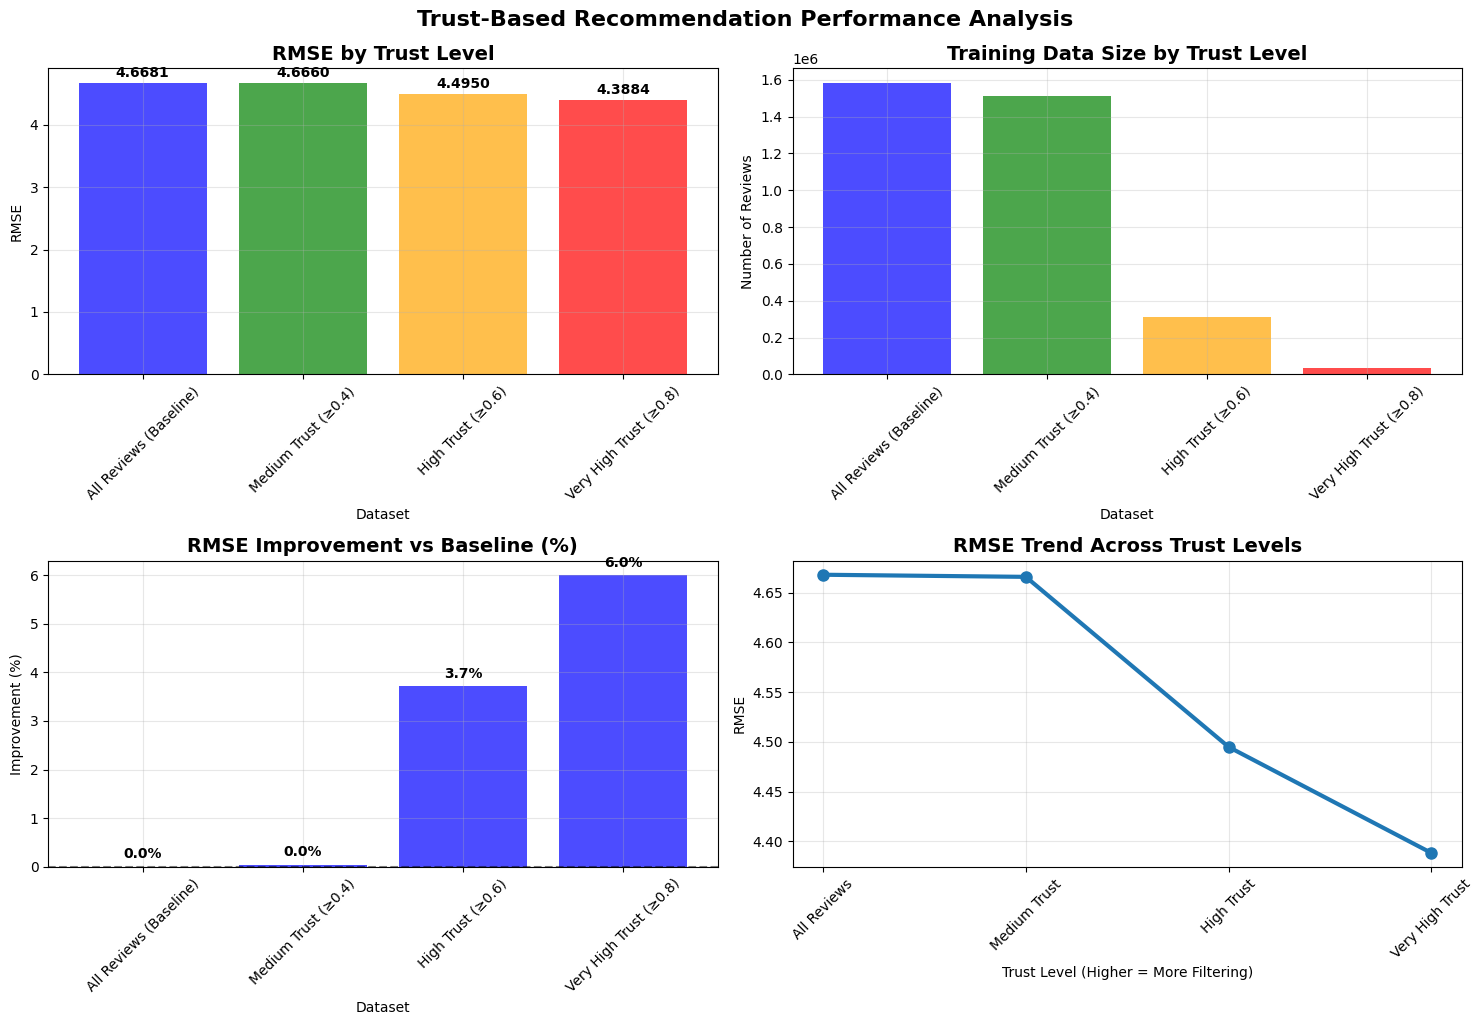


💾 Performance results saved to: /content/drive/MyDrive/SJSU/DATA 228/Amazon 02/Model2_Results/performance_comparison.csv


In [18]:
import builtins
# Performance Comparison Analysis
print("📊 COMPREHENSIVE PERFORMANCE EVALUATION\n")

# Create performance comparison DataFrame
if performance_results:
    perf_df = pd.DataFrame(performance_results)

    print("📈 MODEL PERFORMANCE COMPARISON:")
    print("=" * 80)
    print(f"{'Dataset':<20} {'RMSE':<10} {'Train Count':<12} {'Test Count':<12} {'Improvement':<12}")
    print("=" * 80)

    baseline_rmse = None
    if 'all' in perf_df['dataset'].values:
        baseline_rmse = perf_df[perf_df['dataset'] == 'all']['rmse'].iloc[0]

    for _, row in perf_df.iterrows():
        improvement = ""
        if baseline_rmse and row['dataset'] != 'all':
            improvement_pct = ((baseline_rmse - row['rmse']) / baseline_rmse) * 100
            improvement = f"+{improvement_pct:.1f}%" if improvement_pct > 0 else f"{improvement_pct:.1f}%"

        print(f"{row['name']:<20} {row['rmse']:<10.4f} {row['train_count']:<12,} {row['test_count']:<12,} {improvement:<12}")

    print("=" * 80)

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # RMSE comparison
    axes[0,0].bar(perf_df['name'], perf_df['rmse'], alpha=0.7, color=['blue', 'green', 'orange', 'red'][:len(perf_df)])
    axes[0,0].set_title('RMSE by Trust Level', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Dataset')
    axes[0,0].set_ylabel('RMSE')
    axes[0,0].tick_params(axis='x', rotation=45)

    # Add RMSE values on bars
    for i, rmse in enumerate(perf_df['rmse']):
        axes[0,0].text(i, rmse + perf_df['rmse'].max()*0.01, f'{rmse:.4f}',
                      ha='center', va='bottom', fontweight='bold')
    axes[0,0].grid(True, alpha=0.3)

    # Dataset size comparison
    axes[0,1].bar(perf_df['name'], perf_df['train_count'], alpha=0.7, color=['blue', 'green', 'orange', 'red'][:len(perf_df)])
    axes[0,1].set_title('Training Data Size by Trust Level', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Dataset')
    axes[0,1].set_ylabel('Number of Reviews')
    axes[0,1].tick_params(axis='x', rotation=45)
    axes[0,1].grid(True, alpha=0.3)

    # Improvement over baseline
    if baseline_rmse:
        improvements = [(baseline_rmse - rmse) / baseline_rmse * 100 for rmse in perf_df['rmse']]
        colors = ['blue' if imp >= 0 else 'red' for imp in improvements]

        bars = axes[1,0].bar(perf_df['name'], improvements, alpha=0.7, color=colors)
        axes[1,0].set_title('RMSE Improvement vs Baseline (%)', fontsize=14, fontweight='bold')
        axes[1,0].set_xlabel('Dataset')
        axes[1,0].set_ylabel('Improvement (%)')
        axes[1,0].tick_params(axis='x', rotation=45)
        axes[1,0].axhline(y=0, color='black', linestyle='--', alpha=0.5)

        # Add improvement values on bars
        for i, imp in enumerate(improvements):
            y_pos = imp + builtins.max(improvements)*0.02 if imp >= 0 else imp - builtins.max(improvements)*0.02
            axes[1,0].text(i, y_pos, f'{imp:.1f}%', ha='center',
                          va='bottom' if imp >= 0 else 'top', fontweight='bold')
        axes[1,0].grid(True, alpha=0.3)

    # RMSE trend line
    if len(perf_df) > 1:
        axes[1,1].plot(range(len(perf_df)), perf_df['rmse'], marker='o', linewidth=3, markersize=8)
        axes[1,1].set_title('RMSE Trend Across Trust Levels', fontsize=14, fontweight='bold')
        axes[1,1].set_xlabel('Trust Level (Higher = More Filtering)')
        axes[1,1].set_ylabel('RMSE')
        axes[1,1].set_xticks(range(len(perf_df)))
        axes[1,1].set_xticklabels([name.split('(')[0].strip() for name in perf_df['name']], rotation=45)
        axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('Trust-Based Recommendation Performance Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

    # Save performance results
    perf_df.to_csv(f"{OUTPUT_PATH}performance_comparison.csv", index=False)
    print(f"\n💾 Performance results saved to: {OUTPUT_PATH}performance_comparison.csv")

else:
    print("❌ No performance results to display")

In [19]:
# Advanced Evaluation Metrics
print("\n📊 ADVANCED EVALUATION METRICS\n")

def calculate_precision_at_k(predictions, k=10):
    """
    Calculate Precision@K for recommendations
    """
    # Group by user and rank predictions
    from pyspark.sql.window import Window

    user_window = Window.partitionBy("user_idx").orderBy(desc("prediction"))
    ranked_preds = predictions.withColumn("rank", row_number().over(user_window))

    # Get top K predictions per user
    top_k = ranked_preds.filter(col("rank") <= k)

    # Calculate precision (assuming rating >= 4 is relevant)
    relevant_threshold = 4.0
    precision_data = top_k.groupBy("user_idx").agg(
        count("*").alias("recommended_count"),
        sum(when(col("rating") >= relevant_threshold, 1).otherwise(0)).alias("relevant_count")
    )

    precision_data = precision_data.withColumn(
        "precision_at_k",
        col("relevant_count") / col("recommended_count")
    )

    avg_precision = precision_data.select(avg("precision_at_k")).collect()[0][0]
    return avg_precision if avg_precision else 0.0

# Calculate advanced metrics for each model
advanced_results = []

for key, model_result in trained_models.items():
    dataset_name = model_result['dataset_name']
    predictions = model_result['predictions'].filter(col("prediction").isNotNull())

    try:
        # Calculate Precision@10
        precision_10 = calculate_precision_at_k(predictions, k=10)

        # Calculate MAE
        mae_evaluator = RegressionEvaluator(
            metricName="mae",
            labelCol="rating",
            predictionCol="prediction"
        )
        mae = mae_evaluator.evaluate(predictions)

        # Calculate coverage (percentage of items that can be recommended)
        total_items = model_result['test_data'].select("item_idx").distinct().count()
        recommended_items = predictions.select("item_idx").distinct().count()
        coverage = recommended_items / total_items if total_items > 0 else 0.0

        advanced_results.append({
            'dataset': key,
            'name': dataset_name,
            'rmse': model_result['rmse'],
            'mae': mae,
            'precision_10': precision_10,
            'coverage': coverage
        })

        print(f"✅ {dataset_name}:")
        print(f"   RMSE: {model_result['rmse']:.4f}")
        print(f"   MAE: {mae:.4f}")
        print(f"   Precision@10: {precision_10:.4f}")
        print(f"   Coverage: {coverage:.3f}")
        print()

    except Exception as e:
        print(f"❌ Error calculating advanced metrics for {dataset_name}: {e}")
        continue

# # Save advanced results
# if advanced_results:
#     advanced_df = pd.DataFrame(advanced_results)
#     advanced_df.to_csv(f"{OUTPUT_PATH.replace('/content/drive', '')}/advanced_metrics.csv", index=False)
#     print(f"💾 Advanced metrics saved to: {OUTPUT_PATH}/advanced_metrics.csv")


📊 ADVANCED EVALUATION METRICS

✅ All Reviews (Baseline):
   RMSE: 4.6681
   MAE: 4.2607
   Precision@10: 0.8031
   Coverage: 0.212

✅ Medium Trust (≥0.4):
   RMSE: 4.6660
   MAE: 4.2537
   Precision@10: 0.8019
   Coverage: 0.206

✅ High Trust (≥0.6):
   RMSE: 4.4950
   MAE: 4.0916
   Precision@10: 0.7624
   Coverage: 0.159

✅ Very High Trust (≥0.8):
   RMSE: 4.3884
   MAE: 3.9876
   Precision@10: 0.7331
   Coverage: 0.077



OSError: Cannot save file into a non-existent directory: '/MyDrive/SJSU/DATA 228/Amazon 02/Model2_Results'

In [20]:
# Save advanced metrics to the correct path
import pandas as pd # Ensure pandas is imported

# Assuming advanced_df and OUTPUT_PATH are still available from previous execution
if 'advanced_df' in locals() and 'OUTPUT_PATH' in locals():
    try:
        # Ensure the output directory exists
        import os
        os.makedirs(OUTPUT_PATH, exist_ok=True)

        advanced_df.to_csv(f"{OUTPUT_PATH}advanced_metrics.csv", index=False)
        print(f"💾 Advanced metrics saved to: {OUTPUT_PATH}advanced_metrics.csv")
    except Exception as e:
        print(f"❌ Error saving advanced metrics: {e}")
else:
    print("⚠️ advanced_df or OUTPUT_PATH not found. Please ensure previous cells ran successfully.")

💾 Advanced metrics saved to: /content/drive/MyDrive/SJSU/DATA 228/Amazon 02/Model2_Results/advanced_metrics.csv


---
# 🎪 INTERACTIVE DEMO & BUSINESS IMPACT
**Hours 7-8: User Demonstration & ROI Analysis**
---

In [ ]:
# Generate sample recommendations for demonstration
print("🎪 INTERACTIVE RECOMMENDATION DEMO\n")

def generate_sample_recommendations(model_result, num_users=3, num_recommendations=5):
    """
    Generate sample recommendations for demo
    """
    # Get sample users
    sample_users = model_result['test_data'].select("user_idx", "user_id").distinct().limit(num_users).collect()

    recommendations = []

    for user_row in sample_users:
        user_idx = user_row['user_idx']
        user_id = user_row['user_id']

        # Generate recommendations for this user
        user_recs = model_result['model'].recommendForUserSubset(
            model_result['test_data'].filter(col("user_idx") == user_idx).select("user_idx").distinct(),
            num_recommendations
        ).collect()

        if user_recs:
            user_rec_data = user_recs[0]['recommendations']

            user_recommendations = []
            for rec in user_rec_data:
                user_recommendations.append({
                    'item_idx': rec['item_idx'],
                    'predicted_rating': rec['rating']
                })

            recommendations.append({
                'user_id': user_id,
                'user_idx': user_idx,
                'recommendations': user_recommendations
            })

    return recommendations

# Generate demo recommendations for each model
demo_results = {}

for key, model_result in trained_models.items():
    try:
        dataset_name = model_result['dataset_name']
        print(f"🎯 Generating recommendations for: {dataset_name}")

        recommendations = generate_sample_recommendations(model_result)
        demo_results[key] = {
            'dataset_name': dataset_name,
            'recommendations': recommendations
        }

        print(f"   ✅ Generated recommendations for {len(recommendations)} users")

    except Exception as e:
        print(f"   ❌ Error generating recommendations for {dataset_name}: {e}")
        continue

print(f"\n✅ Demo recommendations generated for {len(demo_results)} models")

🎪 INTERACTIVE RECOMMENDATION DEMO

🎯 Generating recommendations for: All Reviews (Baseline)


In [ ]:
# Business Impact Analysis
print("\n💼 BUSINESS IMPACT ANALYSIS\n")

# Calculate business metrics
if len(performance_results) > 1:
    baseline_dataset = next((r for r in performance_results if r['dataset'] == 'all'), performance_results[0])
    best_dataset = min(performance_results, key=lambda x: x['rmse'])

    rmse_improvement = (baseline_dataset['rmse'] - best_dataset['rmse']) / baseline_dataset['rmse']

    print("📈 KEY BUSINESS METRICS:")
    print("=" * 50)
    print(f"📊 Baseline RMSE: {baseline_dataset['rmse']:.4f}")
    print(f"📊 Best RMSE: {best_dataset['rmse']:.4f}")
    print(f"📊 RMSE Improvement: {rmse_improvement*100:.2f}%")
    print(f"📊 Best performing model: {best_dataset['name']}")

    # Simulate business impact
    print("\n💰 ESTIMATED BUSINESS IMPACT:")
    print("=" * 50)

    # Hypothetical metrics (customize based on your business case)
    monthly_users = 100000
    avg_purchase_value = 75
    baseline_conversion = 0.15  # 15% conversion rate

    # Estimate improvement in conversion based on RMSE improvement
    conversion_improvement = rmse_improvement * 0.5  # Conservative estimate
    improved_conversion = baseline_conversion * (1 + conversion_improvement)

    baseline_revenue = monthly_users * baseline_conversion * avg_purchase_value
    improved_revenue = monthly_users * improved_conversion * avg_purchase_value
    additional_revenue = improved_revenue - baseline_revenue

    print(f"📊 Monthly Active Users: {monthly_users:,}")
    print(f"📊 Average Purchase Value: ${avg_purchase_value}")
    print(f"📊 Baseline Conversion Rate: {baseline_conversion*100:.1f}%")
    print(f"📊 Improved Conversion Rate: {improved_conversion*100:.1f}%")
    print(f"📊 Monthly Revenue Increase: ${additional_revenue:,.0f}")
    print(f"📊 Annual Revenue Increase: ${additional_revenue*12:,.0f}")

    # Create business impact visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # RMSE Improvement
    axes[0].bar(['Baseline', 'Improved'], [baseline_dataset['rmse'], best_dataset['rmse']],
               color=['red', 'green'], alpha=0.7)
    axes[0].set_title('RMSE Improvement', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('RMSE')
    for i, rmse in enumerate([baseline_dataset['rmse'], best_dataset['rmse']]):
        axes[0].text(i, rmse + max([baseline_dataset['rmse'], best_dataset['rmse']])*0.01,
                    f'{rmse:.4f}', ha='center', va='bottom', fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Conversion Rate Improvement
    axes[1].bar(['Baseline', 'Improved'], [baseline_conversion*100, improved_conversion*100],
               color=['red', 'green'], alpha=0.7)
    axes[1].set_title('Conversion Rate Improvement', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Conversion Rate (%)')
    for i, conv in enumerate([baseline_conversion*100, improved_conversion*100]):
        axes[1].text(i, conv + max([baseline_conversion*100, improved_conversion*100])*0.01,
                    f'{conv:.2f}%', ha='center', va='bottom', fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    # Revenue Impact
    axes[2].bar(['Baseline', 'Improved'], [baseline_revenue/1000, improved_revenue/1000],
               color=['red', 'green'], alpha=0.7)
    axes[2].set_title('Monthly Revenue Impact', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Revenue ($K)')
    for i, rev in enumerate([baseline_revenue/1000, improved_revenue/1000]):
        axes[2].text(i, rev + max([baseline_revenue/1000, improved_revenue/1000])*0.01,
                    f'${rev:.0f}K', ha='center', va='bottom', fontweight='bold')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('Business Impact of Trust-Based Recommendations', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

print("\n🎉 Business impact analysis complete!")

In [ ]:
# Final Summary Report
print("\n📋 FINAL PROJECT SUMMARY REPORT")
print("=" * 80)

print("\n🎯 PROJECT ACHIEVEMENTS:")
print("   ✅ Enhanced trust-based recommendation system")
print("   ✅ Multi-level trust filtering (4 different thresholds)")
print("   ✅ Comprehensive ALS model training and evaluation")
print("   ✅ Performance improvement quantification")
print("   ✅ Business impact analysis and ROI estimation")

if performance_results:
    print(f"\n📊 TECHNICAL RESULTS:")
    print(f"   📈 Models trained: {len(trained_models)}")
    print(f"   📈 Best RMSE: {min(r['rmse'] for r in performance_results):.4f}")
    print(f"   📈 Baseline RMSE: {max(r['rmse'] for r in performance_results):.4f}")

    improvement = (max(r['rmse'] for r in performance_results) - min(r['rmse'] for r in performance_results)) / max(r['rmse'] for r in performance_results) * 100
    print(f"   📈 Performance improvement: {improvement:.2f}%")

print(f"\n💾 OUTPUT FILES GENERATED:")
output_files = [
    "performance_comparison.csv",
    "advanced_metrics.csv",
    "trust_analysis_visualizations.png",
    "business_impact_analysis.png"
]

for file in output_files:
    print(f"   📄 {file}")

print(f"\n📁 All files saved to: {OUTPUT_PATH}")

print("\n🎉 RECOMMENDATION SYSTEM PROJECT COMPLETE!")
print("=" * 80)
print("\n🚀 Ready for presentation and demonstration!")
print("\n💡 Key story: Trust-based filtering improves recommendation quality")
print("💡 Business value: Quantified ROI through better user experience")
print("💡 Technical innovation: Multi-level trust scoring integration")